In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
import requests
import io

In [39]:
def get_top_crypto_tickers(top_n=10):

    url = "https://api.coingecko.com/api/v3/coins/markets"
    
    # API parameters
    params = {
        'vs_currency': 'usd',          # Get prices/market cap in USD
        'order': 'market_cap_desc',    # Sort by market cap descending
        'per_page': top_n,             # Number of coins to fetch (max 250)
        'page': 1,                     # Page number
        'sparkline': 'false'           # We don't need the mini price-history charts
    }
    
    try:
        response = requests.get(url, params=params)
        response.raise_for_status() # Check for HTTP errors
        
        # Parse the JSON response into a list of dictionaries
        data = response.json()
        
        # Load the data into a pandas DataFrame for easy viewing
        df = pd.DataFrame(data)
        
        df = df[['market_cap_rank', 'symbol', 'name', 'current_price', 'market_cap']]
        
        # CoinGecko returns symbols like 'btc'. 
        # Yahoo Finance requires 'BTC-USD'. We format that here:
        df['yfinance_ticker'] = df['symbol'].str.upper() + '-USD'
        
        return df

    except requests.exceptions.RequestException as e:
        print(f"Error fetching data: {e}")
        return None

# Run the function
top_cryptos_df = get_top_crypto_tickers(top_n=20)
display(top_cryptos_df)

,market_cap_rank,symbol,name,current_price,market_cap,yfinance_ticker
0,1,btc,Bitcoin,71730.000000,1435594229242,BTC-USD
1,2,eth,Ethereum,2218.660000,267697493740,ETH-USD
2,3,usdt,Tether,1.000000,184417645750,USDT-USD
3,4,xrp,XRP,1.330000,81720692255,XRP-USD
4,5,bnb,BNB,596.010000,81234885292,BNB-USD
5,6,usdc,USDC,1.000000,78631728992,USDC-USD
6,7,sol,Solana,82.430000,47340915897,SOL-USD
7,8,trx,TRON,0.320376,30364657899,TRX-USD
8,9,figr_heloc,Figure Heloc,1.040000,17315077454,FIGR_HELOC-USD
9,10,doge,Dogecoin,0.091448,14059195788,DOGE-USD


In [40]:
top_cryptos_df = top_cryptos_df.drop([0, 1, 2, 5, 8, 10, 15, 19])
top_cryptos_df = top_cryptos_df.reset_index(drop=True)

In [41]:
pca_ticker_list = top_cryptos_df['yfinance_ticker'].tolist()
    
print(pca_ticker_list)

['XRP-USD', 'BNB-USD', 'SOL-USD', 'TRX-USD', 'DOGE-USD', 'WBT-USD', 'HYPE-USD', 'LEO-USD', 'ADA-USD', 'LINK-USD', 'XMR-USD', 'ZEC-USD']


In [42]:
raw_data = yf.download(pca_ticker_list, period='5y', interval='1wk')
close_prices = raw_data['Close']

/tmp/ipykernel_22172/3221198396.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(pca_ticker_list, period='5y', interval='1wk')
[*********************100%***********************]  12 of 12 completed


In [43]:
close_prices.isna().sum()[close_prices.isna().sum() > 0]

,0
Ticker,
HYPE-USD,84
WBT-USD,71


In [44]:
close_prices = close_prices.dropna(axis=1)

In [45]:
btc = yf.download('BTC-USD', period='5y', interval='1wk')
benchmark = btc['Close']

/tmp/ipykernel_22172/1419607031.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download('BTC-USD', period='5y', interval='1wk')
[*********************100%***********************]  1 of 1 completed


In [46]:
X_train, X_test, y_train, y_test = train_test_split(close_prices, benchmark, test_size=0.2, shuffle=False)

In [47]:
log_returns = np.log(X_train/X_train.shift(1)).dropna()

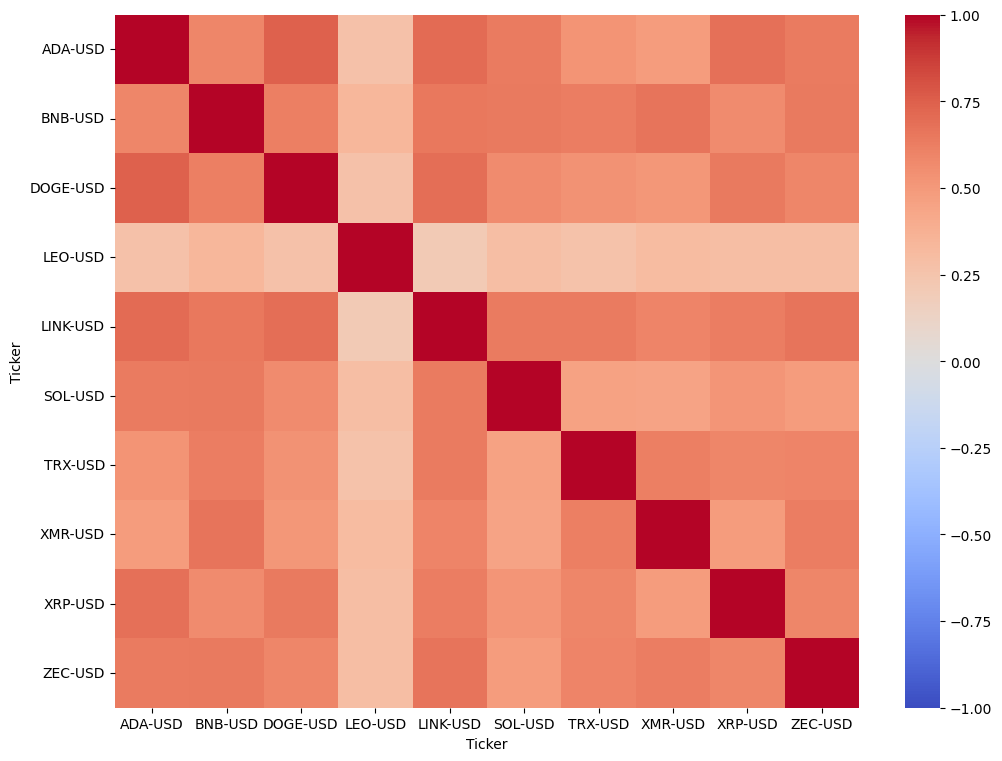

In [48]:
corr_matrix = log_returns.corr()

plt.figure(figsize=(12,9))
sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

In [49]:
scaled_log_returns = StandardScaler().fit_transform(log_returns)

pca = PCA(n_components=5)
pca.fit(scaled_log_returns)

PCA(n_components=5)

In [50]:
pca.explained_variance_ratio_

array([0.59533194, 0.08960934, 0.07431225, 0.05547614, 0.04287744])

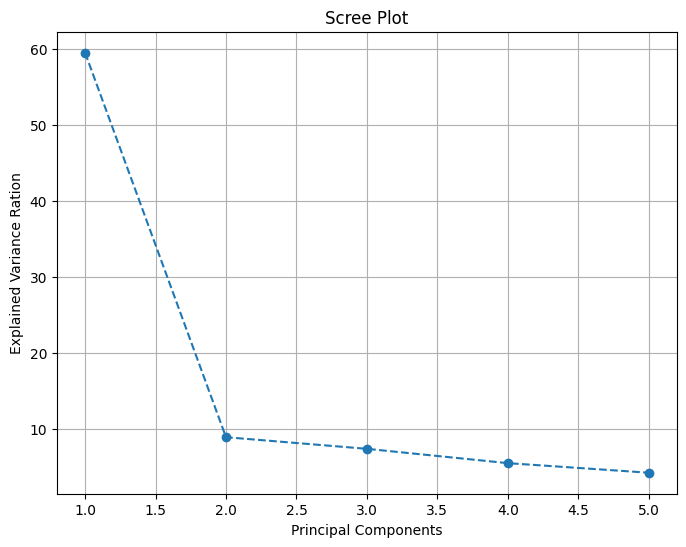

In [51]:
plt.figure(figsize=(8, 6))
plt.plot(range(1,6), pca.explained_variance_ratio_ * 100, marker='o', linestyle='--')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ration')
plt.title('Scree Plot')
plt.grid()
plt.show()

In [52]:
pca.components_[0]

array([0.3419636 , 0.34253055, 0.33492397, 0.16708429, 0.35065481,
       0.30555531, 0.31526566, 0.30881642, 0.32385139, 0.33117957])

In [53]:
pc1_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[0] * 100
})

pc1_sorted = pc1_df.sort_values(by='Weight', ascending=False)

display(pc1_sorted)

,Ticker,Weight
4,LINK-USD,35.065481
1,BNB-USD,34.253055
0,ADA-USD,34.196360
2,DOGE-USD,33.492397
9,ZEC-USD,33.117957
8,XRP-USD,32.385139
6,TRX-USD,31.526566
7,XMR-USD,30.881642
5,SOL-USD,30.555531
3,LEO-USD,16.708429


In [54]:
pc2_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[1] * 100
})

pc2_sorted = pc2_df.sort_values(by='Weight', ascending=False)
display(pc2_sorted)

,Ticker,Weight
3,LEO-USD,92.524485
7,XMR-USD,15.022510
1,BNB-USD,8.441178
6,TRX-USD,-0.047356
9,ZEC-USD,-0.234847
5,SOL-USD,-3.174756
8,XRP-USD,-8.447919
2,DOGE-USD,-15.768526
0,ADA-USD,-18.135355
4,LINK-USD,-21.982925


In [55]:
pc3_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[2] * 100
})

pc3_sorted = pc3_df.sort_values(by='Weight', ascending=False)

display(pc3_sorted)

,Ticker,Weight
7,XMR-USD,54.224074
6,TRX-USD,42.907400
9,ZEC-USD,22.203397
1,BNB-USD,16.276637
4,LINK-USD,0.144900
8,XRP-USD,-17.776059
3,LEO-USD,-25.021868
2,DOGE-USD,-28.133570
0,ADA-USD,-36.452246
5,SOL-USD,-37.395426


In [56]:
# ==============================================================================
# 1. CORE MATH & PORTFOLIO SIMULATION ENGINES
# ==============================================================================
def extract_strategy_weights(pca_model, columns, pc_index, strategy_type='auto'):
    """Extracts and normalizes weights based on the chosen strategy."""
    raw_weights = pca_model.components_[pc_index]
    
    # Auto-detect strategy: PC1 is usually Long-Only, everything else is Long/Short
    if strategy_type == 'auto':
        strategy_type = 'long_only' if pc_index == 0 else 'long_short'
        
    if strategy_type == 'long_only':
        # Fix sign direction for PC1
        if np.sum(raw_weights) < 0:
            raw_weights = -raw_weights
        long_weights = np.maximum(0, raw_weights)
        return pd.Series(long_weights / np.sum(long_weights), index=columns), 'Long-Only'
        
    elif strategy_type == 'long_short':
        # Normalize Longs to +1.0 and Shorts to -1.0 (Dollar Neutral)
        longs = np.maximum(0, raw_weights)
        shorts = np.minimum(0, raw_weights)
        norm_longs = longs / np.sum(longs) if np.sum(longs) > 0 else longs
        norm_shorts = shorts / abs(np.sum(shorts)) if np.sum(shorts) < 0 else shorts
        return pd.Series(norm_longs + norm_shorts, index=columns), 'Long/Short (Market Neutral)'

def simulate_portfolio(price_data, weights, initial_capital, strategy_name):
    """Simulates the portfolio equity curve based on strategy type."""
    initial_prices = price_data.iloc[0]
    shares = (initial_capital * weights) / initial_prices
    
    if strategy_name == 'Long-Only':
        # Portfolio value is just the current value of the shares held
        return price_data.dot(shares)
    else:
        # Long/Short Portfolio: Initial Capital is margin. 
        # PnL = (Current Prices * Shares). Note: Shorts are negative shares, so dropping prices = profit.
        return initial_capital + price_data.dot(shares)

def align_benchmark(benchmark_data, initial_capital):
    """Normalizes the benchmark to start at the exact same capital as the portfolio."""
    if isinstance(benchmark_data, pd.DataFrame):
        benchmark_data = benchmark_data.iloc[:, 0]
    return (benchmark_data / benchmark_data.iloc[0]) * initial_capital

# ==============================================================================
# 2. INSTITUTIONAL METRICS ENGINE
# ==============================================================================
def calculate_metrics(port_val, bench_val, rf_rate, periods_per_yr):
    df = pd.concat([port_val, bench_val], axis=1).dropna()
    df.columns = ['Portfolio', 'Benchmark']
    
    returns = df.pct_change().dropna()
    p_ret, b_ret = returns['Portfolio'], returns['Benchmark']
    
    # CAGR
    ann_p_ret = (df['Portfolio'].iloc[-1] / df['Portfolio'].iloc[0]) ** (periods_per_yr / len(returns)) - 1
    ann_b_ret = (df['Benchmark'].iloc[-1] / df['Benchmark'].iloc[0]) ** (periods_per_yr / len(returns)) - 1
    
    # Volatility
    ann_p_vol = p_ret.std() * np.sqrt(periods_per_yr)
    ann_b_vol = b_ret.std() * np.sqrt(periods_per_yr)
    
    # Sharpe
    p_sharpe = (ann_p_ret - rf_rate) / ann_p_vol
    b_sharpe = (ann_b_ret - rf_rate) / ann_b_vol
    
    # Sortino
    p_down_dev = np.sqrt(np.mean(np.where(p_ret < 0, p_ret**2, 0))) * np.sqrt(periods_per_yr)
    p_sortino = (ann_p_ret - rf_rate) / p_down_dev if p_down_dev > 0 else np.nan
    b_down_dev = np.sqrt(np.mean(np.where(b_ret < 0, b_ret**2, 0))) * np.sqrt(periods_per_yr)
    b_sortino = (ann_b_ret - rf_rate) / b_down_dev if b_down_dev > 0 else np.nan
    
    # Drawdowns
    p_dd = (df['Portfolio'] - df['Portfolio'].cummax()) / df['Portfolio'].cummax()
    b_dd = (df['Benchmark'] - df['Benchmark'].cummax()) / df['Benchmark'].cummax()
    
    # Beta & Alpha
    cov = np.cov(p_ret, b_ret)
    beta = cov[0, 1] / cov[1, 1]
    alpha = ann_p_ret - (rf_rate + beta * (ann_b_ret - rf_rate))
    
    # Calmar
    p_calmar = ann_p_ret / abs(p_dd.min())
    b_calmar = ann_b_ret / abs(b_dd.min())
    
    metrics = pd.DataFrame({
        'Portfolio': [f"{ann_p_ret*100:.2f}%", f"{ann_p_vol*100:.2f}%", f"{p_sharpe:.2f}", f"{p_sortino:.2f}", f"{p_dd.min()*100:.2f}%", f"{p_calmar:.2f}", f"{beta:.2f}", f"{alpha*100:.2f}%"],
        'Benchmark': [f"{ann_b_ret*100:.2f}%", f"{ann_b_vol*100:.2f}%", f"{b_sharpe:.2f}", f"{b_sortino:.2f}", f"{b_dd.min()*100:.2f}%", f"{b_calmar:.2f}", "1.00", "0.00%"]
    }, index=['Return (CAGR)', 'Volatility', 'Sharpe Ratio', 'Sortino Ratio', 'Max Drawdown', 'Calmar Ratio', 'Beta', "Jensen's Alpha"])
    
    return metrics, p_dd, b_dd, p_ret, b_ret

# ==============================================================================
# 3. MASTER WRAPPER & PLOTTING DASHBOARD
# ==============================================================================
def evaluate_pc_strategy(pca_model, pc_index, price_data, benchmark_data, strategy='auto', initial_capital=100000, rf_rate=0.06, periods_per_yr=52):
    """
    The Ultimate Master Function. Put in a PC index, get out the full institutional dashboard.
    """
    # 1. Build Portfolio
    weights, strat_name = extract_strategy_weights(pca_model, price_data.columns, pc_index, strategy)
    port_val = simulate_portfolio(price_data, weights, initial_capital, strat_name)
    bench_val = align_benchmark(benchmark_data, initial_capital)
    
    # 2. Get Metrics
    metrics_df, p_dd, b_dd, p_ret, b_ret = calculate_metrics(port_val, bench_val, rf_rate, periods_per_yr)
    
    # 3. Print Results
    actual_pc = pc_index + 1
    print("\n" + "="*65)
    print(f" STRATEGY REPORT: Principal Component {actual_pc} [{strat_name}]")
    print("="*65)
    display(metrics_df)
    
    # 4. Render Dashboard
    fig = plt.figure(figsize=(14, 12))
    gs = fig.add_gridspec(3, 1, height_ratios=[2.5, 1, 1], hspace=0.3)
    
    # Chart 1: Equity Curve
    ax1 = fig.add_subplot(gs[0])
    ax1.plot(port_val.index, (port_val/initial_capital)*100, label=f'PC{actual_pc} Portfolio', color='#1f77b4', linewidth=2.5)
    ax1.plot(bench_val.index, (bench_val/initial_capital)*100, label='Benchmark', color='#4a4a4a', linewidth=1.5, alpha=0.8)
    ax1.set_title(f'Equity Curve (Normalized to 100 Base)', fontsize=14, fontweight='bold', loc='left')
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend(loc='upper left')
    
    # Chart 2: Drawdowns
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    ax2.fill_between(p_dd.index, p_dd * 100, 0, color='#d62728', alpha=0.3, label='Portfolio Drawdown')
    ax2.plot(b_dd.index, b_dd * 100, color='black', linewidth=1.2, alpha=0.7, label='Benchmark Drawdown')
    ax2.set_title('Underwater Plot (Capital Drawdowns %)', fontsize=12, fontweight='bold', loc='left')
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend(loc='lower right')
    
    # Chart 3: Rolling Beta
    ax3 = fig.add_subplot(gs[2], sharex=ax1)
    rolling_window = max(int(periods_per_yr / 2), 1) # 6-month rolling window
    rolling_beta = p_ret.rolling(window=rolling_window).cov(b_ret) / b_ret.rolling(window=rolling_window).var()
    ax3.plot(rolling_beta.index, rolling_beta, color='#2ca02c', linewidth=2, label=f'Rolling {rolling_window}-Period Beta')
    ax3.axhline(1.0 if strat_name == 'Long-Only' else 0.0, color='black', linestyle='--', alpha=0.5, label='Target Beta')
    ax3.set_title(f'Systemic Risk (Rolling {rolling_window}-Period Beta)', fontsize=12, fontweight='bold', loc='left')
    ax3.grid(True, linestyle='--', alpha=0.5)
    ax3.legend(loc='lower left')
    
    plt.show()




 STRATEGY REPORT: Principal Component 1 [Long-Only]


,Portfolio,Benchmark
Return (CAGR),100.36%,-14.28%
Volatility,78.38%,38.15%
Sharpe Ratio,1.20,-0.53
Sortino Ratio,2.15,-0.76
Max Drawdown,-58.68%,-46.78%
Calmar Ratio,1.71,-0.31
Beta,1.02,1.00
Jensen's Alpha,115.08%,0.00%


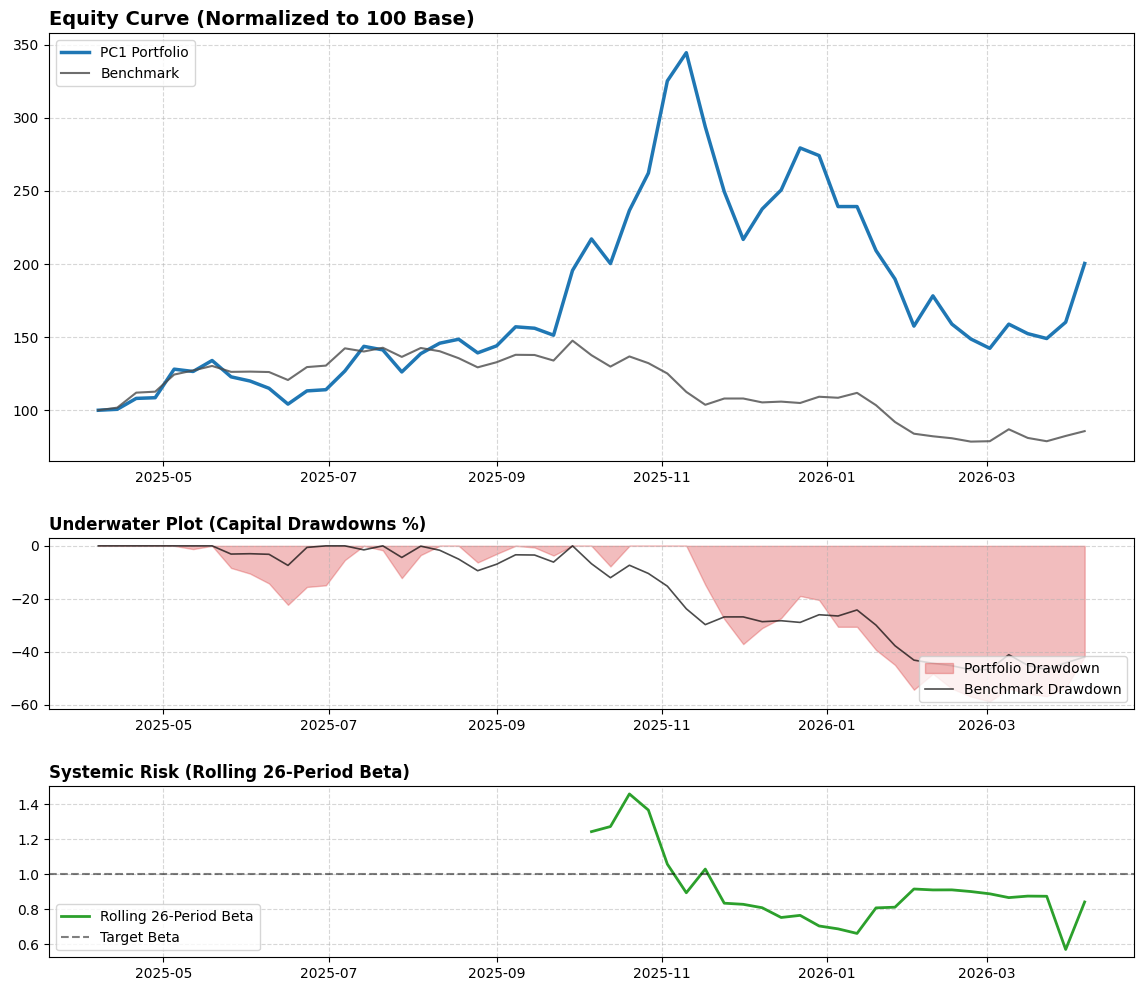

In [57]:
# Test PC1
evaluate_pc_strategy(pca_model=pca, pc_index=0, price_data=X_test, benchmark_data=y_test, periods_per_yr=52)


 STRATEGY REPORT: Principal Component 2 [Long/Short (Market Neutral)]


,Portfolio,Benchmark
Return (CAGR),54.60%,-14.28%
Volatility,101.19%,38.15%
Sharpe Ratio,0.48,-0.53
Sortino Ratio,0.71,-0.76
Max Drawdown,-60.73%,-46.78%
Calmar Ratio,0.90,-0.31
Beta,-1.30,1.00
Jensen's Alpha,22.19%,0.00%


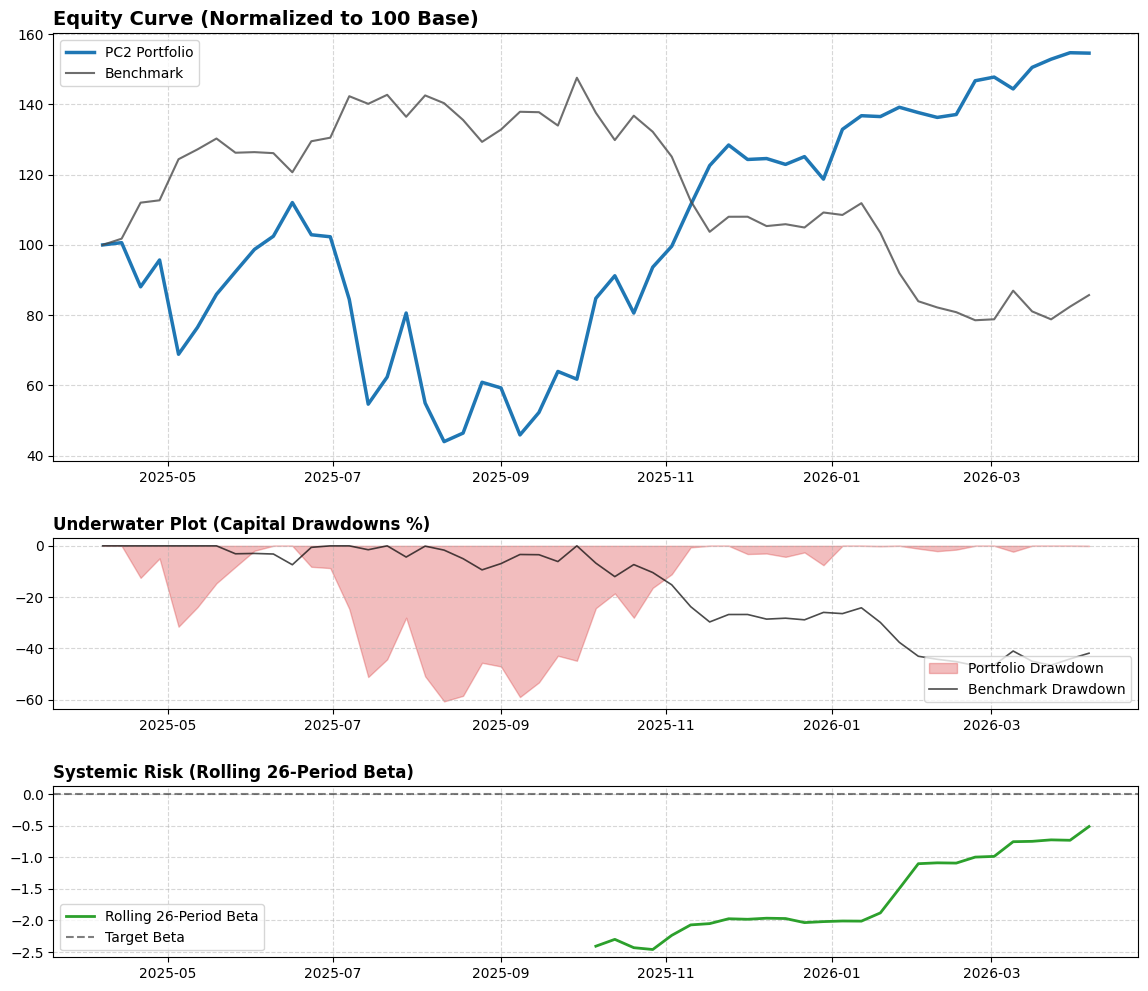

In [58]:
# Test PC2
evaluate_pc_strategy(pca_model=pca, pc_index=1, price_data=X_test, benchmark_data=y_test, periods_per_yr=52)


 STRATEGY REPORT: Principal Component 3 [Long/Short (Market Neutral)]


,Portfolio,Benchmark
Return (CAGR),245.71%,-14.28%
Volatility,100.08%,38.15%
Sharpe Ratio,2.40,-0.53
Sortino Ratio,5.59,-0.76
Max Drawdown,-49.32%,-46.78%
Calmar Ratio,4.98,-0.31
Beta,0.23,1.00
Jensen's Alpha,244.32%,0.00%


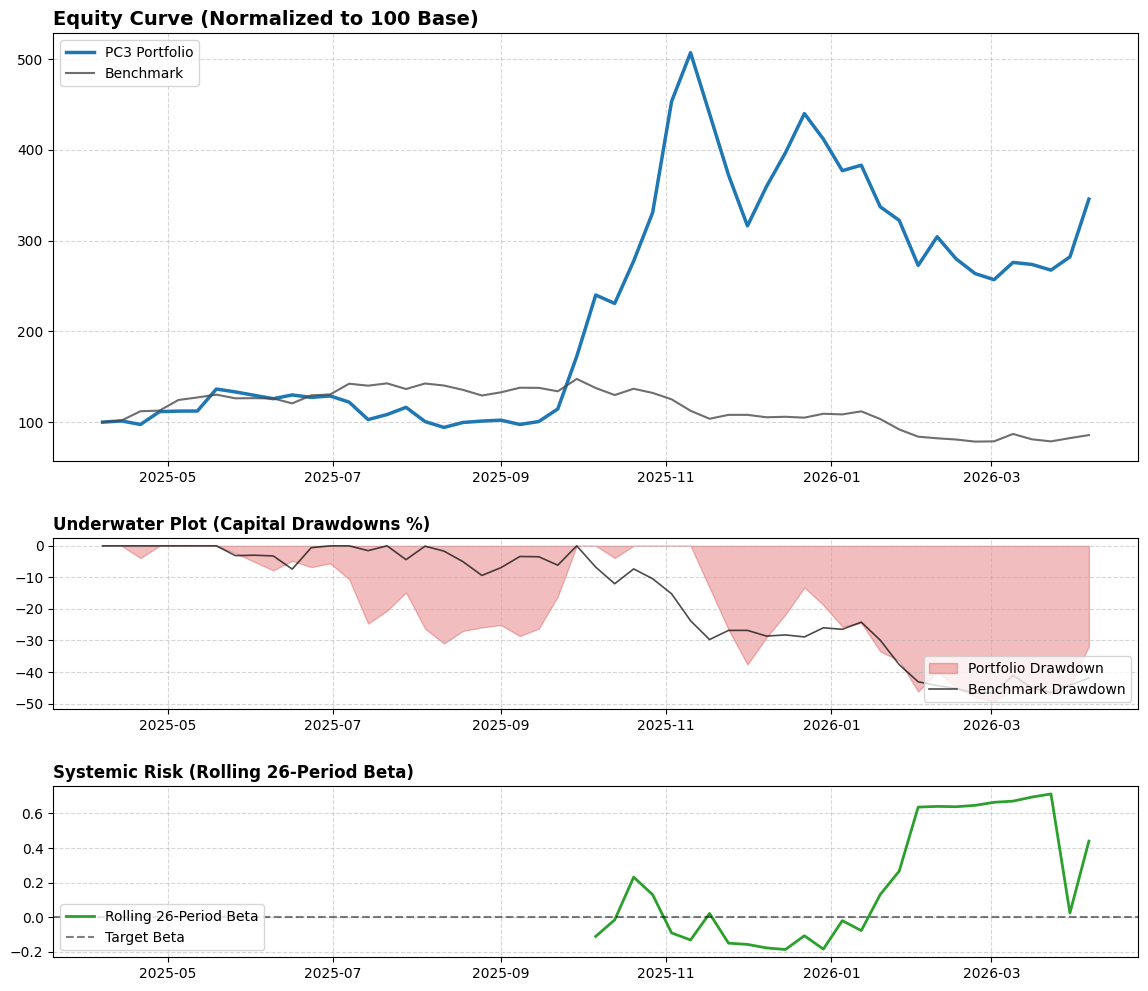

In [59]:
# Test PC3
evaluate_pc_strategy(pca_model=pca, pc_index=2, price_data=X_test, benchmark_data=y_test, periods_per_yr=52)


 STRATEGY REPORT: Principal Component 4 [Long/Short (Market Neutral)]


,Portfolio,Benchmark
Return (CAGR),-108.77%,-14.28%
Volatility,1570.22%,38.15%
Sharpe Ratio,-0.07,-0.53
Sortino Ratio,-0.07,-0.76
Max Drawdown,-179.40%,-46.78%
Calmar Ratio,-0.61,-0.31
Beta,1.26,1.00
Jensen's Alpha,-89.24%,0.00%


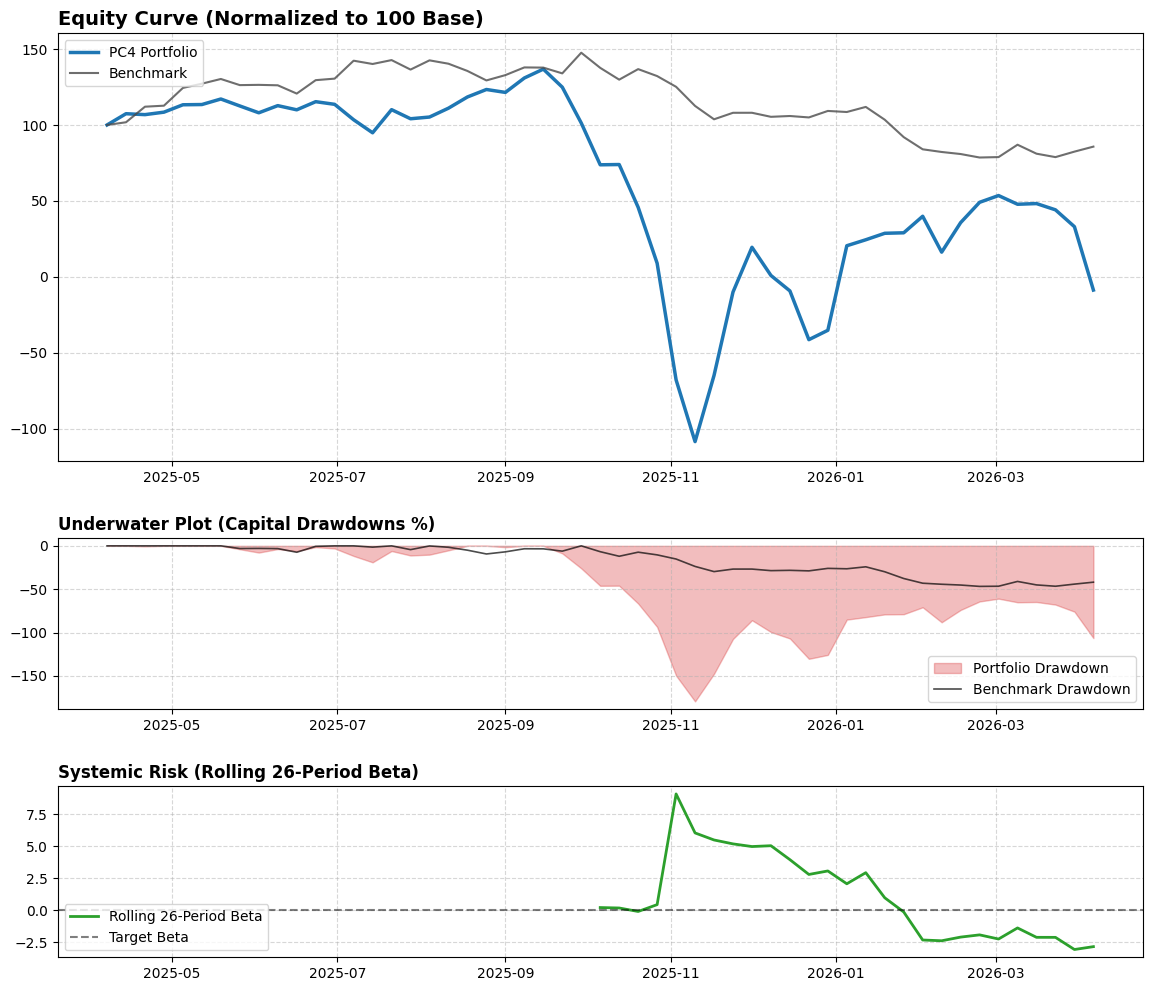

In [60]:
# Test PC4
evaluate_pc_strategy(pca_model=pca, pc_index=3, price_data=X_test, benchmark_data=y_test, periods_per_yr=52)